# Fase 4: Tablero Interpretativo y Recomendaciones

**Project Terra** — Tablero visual que consolida los perfiles de cada clúster y sirve como base de un sistema de recomendación preliminar de cultivos según condiciones ambientales. Complementa a la app interactiva de Streamlit (`app/`) como reporte estático y reproducible.

> Requiere que `03_clustering_model.ipynb` se haya ejecutado previamente para generar `data/processed/sensor_Crop_Dataset_clustered.csv` y los modelos en `data/models/`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from math import pi
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Carga de Datos

In [2]:
clustered_path = "../data/processed/sensor_Crop_Dataset_clustered.csv"
df = pd.read_csv(clustered_path)

cluster_col = 'kmeans_cluster'
target = 'Crop'
feature_cols = ['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity', 'pH_Value', 'Rainfall']

models_dir = Path('../data/models')
scaler = joblib.load(models_dir / 'scaler.joblib')
kmeans_model = joblib.load(models_dir / f'kmeans_k{df[cluster_col].nunique()}.joblib')

# Nombres legibles de las columnas, para usar en títulos y ejes de los gráficos
nombres_legibles = {
    'Nitrogen': 'Nitrógeno',
    'Phosphorus': 'Fósforo',
    'Potassium': 'Potasio',
    'Temperature': 'Temperatura',
    'Humidity': 'Humedad',
    'pH_Value': 'Valor del pH',
    'Rainfall': 'Precipitación',
}

print(f"Dimensiones: {df.shape}")
df.head()

Dimensiones: (20000, 12)


,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop,Soil_Type,Variety,kmeans_cluster,hierarchical_cluster
0,69.074766,53.954402,88.067625,17.261834,72.941652,4.631301,302.842639,Wheat,Clay,Soft Red,1,4
1,107.329352,70.102134,32.081067,21.846116,99.361954,4.761658,94.693847,Tomato,Clay,Beefsteak,3,3
2,130.634624,67.204533,28.294252,33.246895,81.506836,6.566007,83.563685,Sugarcane,Clay,Co 86032,3,2
3,15.169301,87.493181,14.336679,14.396289,59.274465,6.296297,31.508836,Sugarcane,Silt,Co 0238,3,3
4,21.881965,89.269712,38.833885,16.773218,51.191584,8.268274,295.193482,Maize,Sandy,Sweet,2,1


## 2. Visualización de Clústeres
El PCA se calcula sobre las variables ya estandarizadas (mismo `scaler` de `03_clustering_model.ipynb`); aun así, como las 7 variables están casi descorrelacionadas entre sí (ver EDA), PC1 y PC2 no concentran mucha varianza y su proyección 2D separa poco los 5 clústeres. Por eso, junto al PCA, graficamos también `Humidity` vs. `pH_Value` — las dos variables con mayor poder discriminante según la prueba de Kruskal-Wallis (ver `04_cluster_profiling.ipynb`) — donde la separación, aunque no perfecta (algunas ecorregiones se solapan parcialmente), es más clara que en el PCA.

C:\Users\carli\Documents\Project_Terra\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


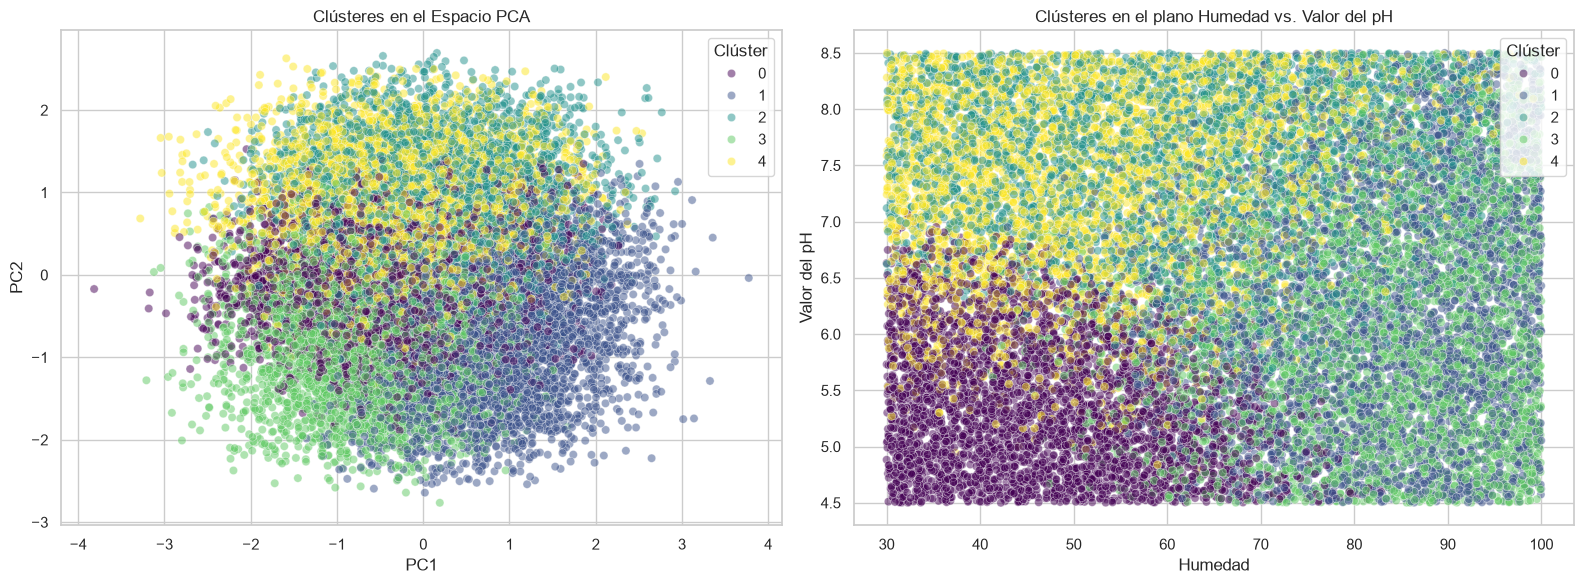

In [3]:
X_scaled = scaler.transform(df[feature_cols])
components = PCA(n_components=2).fit_transform(X_scaled)

df_plot = df.copy()
df_plot['PC1'] = components[:, 0]
df_plot['PC2'] = components[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue=cluster_col, palette='viridis', alpha=0.5, ax=axes[0])
axes[0].set_title('Clústeres en el Espacio PCA')
axes[0].legend(title='Clúster')

sns.scatterplot(data=df_plot, x='Humidity', y='pH_Value', hue=cluster_col, palette='viridis', alpha=0.5, ax=axes[1])
axes[1].set_title('Clústeres en el plano Humedad vs. Valor del pH')
axes[1].set_xlabel('Humedad')
axes[1].set_ylabel('Valor del pH')
axes[1].legend(title='Clúster')

plt.tight_layout()
plt.show()

## 3. Radar — Firma Ambiental por Clúster

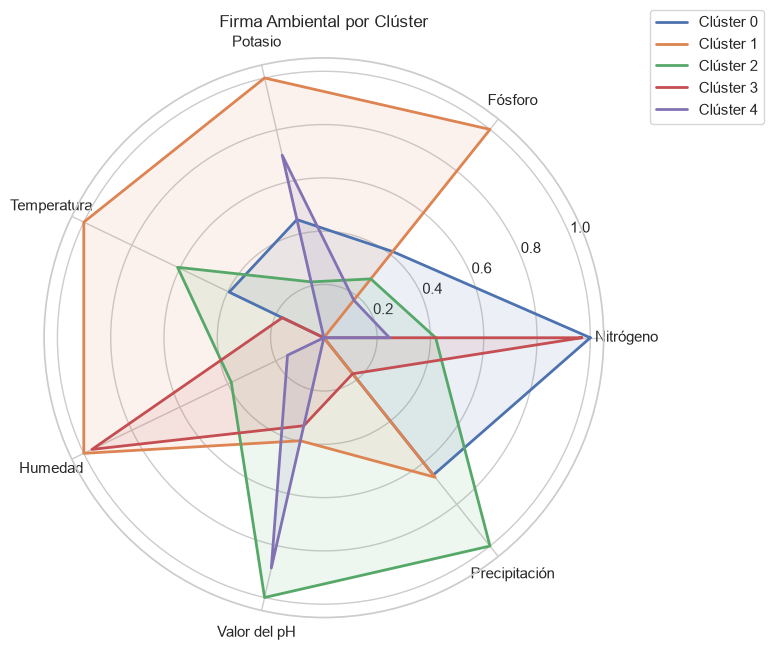

In [4]:
cluster_means = df.groupby(cluster_col)[feature_cols].mean()
cluster_means_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

categories = [nombres_legibles[c] for c in feature_cols]
n_vars = len(categories)
angles = [n / float(n_vars) * 2 * pi for n in range(n_vars)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for cluster_id, row in cluster_means_norm.iterrows():
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=f'Clúster {cluster_id}')
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_title('Firma Ambiental por Clúster')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

## 4. Distribución de Cultivos por Clúster

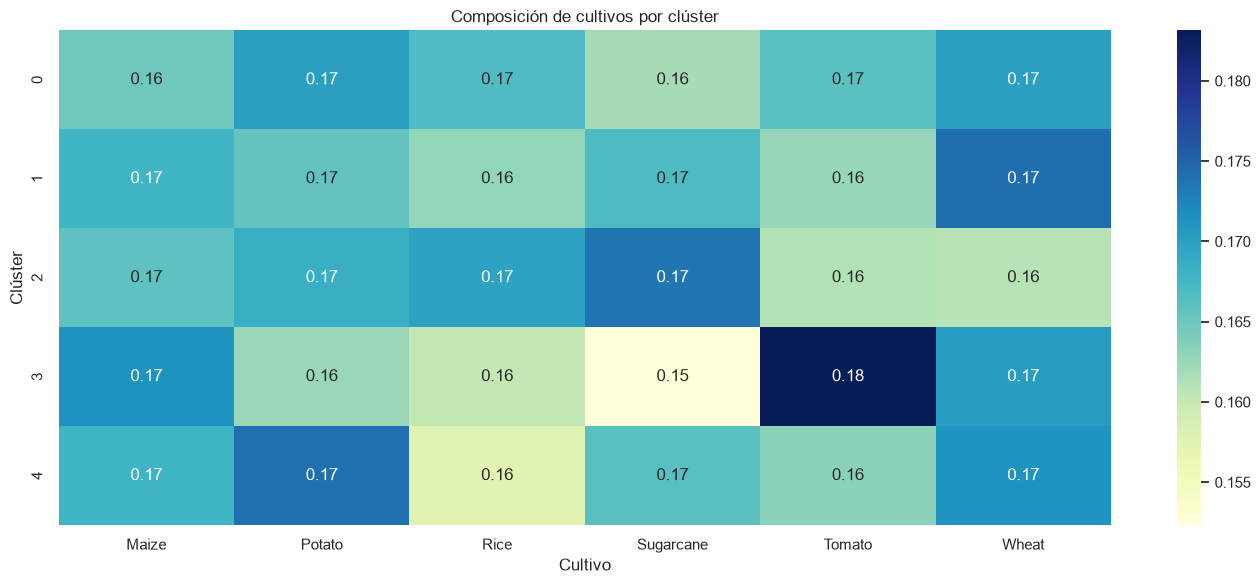

In [5]:
crosstab = pd.crosstab(df[cluster_col], df[target])
crosstab_share = crosstab.div(crosstab.sum(axis=1), axis=0)

plt.figure(figsize=(14, 6))
sns.heatmap(crosstab_share, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Composición de cultivos por clúster')
plt.xlabel('Cultivo')
plt.ylabel('Clúster')
plt.tight_layout()
plt.show()

## 5. Tabla Resumen de Perfiles

In [6]:
summary = df.groupby(cluster_col)[feature_cols].mean().round(2)
summary['n_registros'] = df[cluster_col].value_counts().sort_index()
summary['cultivo_dominante'] = crosstab.idxmax(axis=1)
summary

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,n_registros,cultivo_dominante
kmeans_cluster,,,,,,,,,
0,78.89,47.58,53.74,27.33,46.90,5.37,242.70,4027,Potato
1,75.40,49.71,79.42,28.54,82.48,6.23,244.91,4248,Wheat
2,76.86,47.11,42.45,27.76,60.62,7.54,310.42,3816,Sugarcane
3,78.78,46.09,32.32,26.88,81.27,6.11,146.29,3926,Tomato
4,76.26,46.74,65.42,26.53,52.29,7.29,111.94,3983,Potato


## 6. Sistema de Recomendación Preliminar
Dado un nuevo registro con variables de suelo/clima en su escala real (ppm, °C, mm, etc.), usamos el `scaler` y el modelo `KMeans` ya entrenados y guardados en `data/models/` (ver `03_clustering_model.ipynb`) para escalarlo, asignarlo a su clúster, y recomendar el cultivo dominante de esa ecorregión.

In [7]:
def recomendar_cultivo(nuevo_registro):
    """Recibe un dict con las variables en su escala real (ppm, °C, mm, etc.) y devuelve
    el clúster asignado por el modelo K-Means entrenado y su cultivo dominante."""
    valores = np.array([[nuevo_registro[col] for col in feature_cols]])
    valores_escalados = scaler.transform(valores)
    cluster_asignado = int(kmeans_model.predict(valores_escalados)[0])
    cultivo_recomendado = crosstab.loc[cluster_asignado].idxmax()
    return cluster_asignado, cultivo_recomendado

# Ejemplo de uso: un registro con las condiciones promedio del dataset
ejemplo = {col: float(df[col].mean()) for col in feature_cols}
cluster_id, cultivo = recomendar_cultivo(ejemplo)
print(f"Clúster asignado: {cluster_id} | Cultivo recomendado: {cultivo}")

Clúster asignado: 1 | Cultivo recomendado: Wheat


## 7. Conclusiones prácticas y estratégicas

- **Ecorregiones funcionales identificadas**: con K=5, las variables que realmente separan los clústeres son otras que con K=4: la prueba de Kruskal-Wallis (`04_cluster_profiling.ipynb`) ubica a `Humidity` (H≈10,717), `pH_Value` (H≈9,479), `Rainfall` (H≈8,489) y `Potassium` (H≈8,282) muy por encima de `Temperature` (H≈100), `Phosphorus` (H≈52) y `Nitrogen` (H≈22). Es decir, la partición depende sobre todo de humedad, pH, precipitación y potasio — no de nitrógeno/fósforo como ocurría con K=4. Esto confirma que la elección de K no solo cambia cuántos grupos hay, sino también qué variables terminan 'definiendo' esos grupos.
- **Valor práctico**: la función `recomendar_cultivo()` usa el `scaler` y el `KMeans` reales del pipeline para clasificar un registro nuevo; un registro con las condiciones promedio del dataset se asigna a un clúster concreto y recomienda su cultivo dominante (ver salida de la celda anterior).
- **Limitaciones**: la pureza global de las ecorregiones respecto al cultivo real es de apenas **17.50%** (prácticamente la misma proporción que tendría escoger el cultivo más común al azar, ~16-17%), y la composición de `Soil_Type` también es casi idéntica entre clústeres (~15-18% cada tipo en todos). El 'cultivo recomendado' por clúster debe tomarse como una aproximación preliminar y no como una regla agronómica validada.
- **Próximos pasos**: (a) repetir el clustering usando solo `Humidity`/`pH_Value`/`Rainfall`/`Potassium` (las variables con mayor poder discriminante real) para ver si se obtienen grupos más nítidos; (b) incorporar `Soil_Type` y `Variety` como variables categóricas (one-hot), ya que hoy no aportan señal al clustering numérico; (c) validar el sistema con datos de campo reales antes de usarlo como recomendador definitivo.